<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
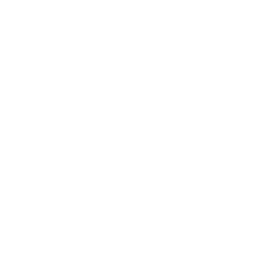
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Grant Disbursement Ledger with Running Totals</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Government / Federal Grants Management &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Print grant payment history with running SUM totals by agency and fiscal year for congressional reporting. The ledger uses BY-group processing on agency code and fiscal year so that disbursements are organized hierarchically, and the PROC PRINT SUM statement produces a grand total across all BY groups for control-total reconciliation. A companion PROC SQL reconciliation joins each disbursement back to its grant award to compute remaining balance and percent drawn, flagging grants that have been over-drawn against their appropriation. The worked example covers 100 disbursement transactions spanning 12 federal agencies and two fiscal years (FY2025 and FY2026), supporting Government Accountability Office review and Single Audit Act compliance.


## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.DISBURSEMENTS | Grant payment transaction ledger | 100 |
| WORK.GRANT_MASTER | Grant award header information | 80 |
| WORK.LEDGER_DETAIL | Disbursements merged with award detail | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic grant master dataset
   -------------------------------------------------------- */
data work.grant_master;
    call streaminit(42);
    length grant_id $12 agency_code $8 agency_name $35 cfda_number $8 grantee_name $40 grant_type $15;
    array agencies[12] $8 _temporary_ ('HHS' 'DOE' 'EPA' 'DOT' 'USDA' 'DOD' 'ED' 'HUD' 'DOJ' 'NSF' 'NASA' 'DOI');
    array agency_names[12] $35 _temporary_ ('Health and Human Services' 'Dept of Energy' 'Environmental Protection Agency' 'Dept of Transportation' 'Dept of Agriculture' 'Dept of Defense' 'Dept of Education' 'Housing and Urban Development' 'Dept of Justice' 'National Science Foundation' 'NASA' 'Dept of the Interior');
    array grant_types[4] $15 _temporary_ ('FORMULA' 'COMPETITIVE' 'BLOCK' 'COOPERATIVE');
    array grantees[15] $40 _temporary_ ('STATE OF CALIFORNIA' 'CITY OF CHICAGO' 'UNIV OF MICHIGAN' 'STATE OF TEXAS' 'NYC DEPT OF HEALTH' 'MASS GENERAL HOSPITAL' 'STATE OF FLORIDA' 'COUNTY OF LOS ANGELES' 'STANFORD UNIVERSITY' 'STATE OF NEW YORK' 'JOHNS HOPKINS UNIV' 'CITY OF HOUSTON' 'STATE OF OHIO' 'DUKE UNIVERSITY' 'CITY OF PHOENIX');
    do grant_seq = 1 to 80;
        grant_id = cat('GR-', put(grant_seq, z6.));
        ag_idx = int(rand('uniform') * 12) + 1;
        agency_code = agencies[ag_idx];
        agency_name = agency_names[ag_idx];
        cfda_number = cat(put(int(rand('uniform') * 90) + 10, z2.), '.', put(int(rand('uniform') * 900) + 100, z3.));
        gt_idx = int(rand('uniform') * 4) + 1;
        grant_type = grant_types[gt_idx];
        gr_idx = int(rand('uniform') * 15) + 1;
        grantee_name = grantees[gr_idx];
        award_amount = round(rand('exponential') * 500000 + 50000, 1);
        award_date = '01OCT2024'd + int(rand('uniform') * 365);
        period_start = award_date;
        period_end = award_date + int(rand('uniform') * 365) + 180;
        output;
    end;
    drop grant_seq ag_idx gt_idx gr_idx;
    format award_date period_start period_end date9. award_amount dollar14.2;
    label grant_id = 'Grant ID'
          agency_code = 'Agency'
          agency_name = 'Agency Name'
          cfda_number = 'CFDA Number'
          grant_type = 'Grant Type'
          grantee_name = 'Grantee'
          award_amount = 'Award Amount'
          award_date = 'Award Date';
run;

NOTE: DATA work.grant_master


NOTE: Wrote work.grant_master (80 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


In [2]:
/* --------------------------------------------------------
   Generate synthetic disbursement transactions
   Multiple payments per grant across fiscal years
   -------------------------------------------------------- */
data work.disbursements;
    call streaminit(43);
    length grant_id $12 payment_type $15 fiscal_year $7;
    array pay_types[4] $15 _temporary_ ('ADVANCE' 'REIMBURSEMENT' 'PROGRESS' 'FINAL');
    do disb_seq = 1 to 500;
        grant_seq = int(rand('uniform') * 80) + 1;
        grant_id = cat('GR-', put(grant_seq, z6.));
        pt_idx = int(rand('uniform') * 4) + 1;
        payment_type = pay_types[pt_idx];
        payment_date = '01OCT2024'd + int(rand('uniform') * 540);
        if month(payment_date) >= 10 then
            fiscal_year = cat('FY', put(year(payment_date) + 1, 4.));
        else
            fiscal_year = cat('FY', put(year(payment_date), 4.));
        payment_amount = round(rand('exponential') * 75000 + 5000, 0.01);
        treasury_symbol = cat('X-', put(int(rand('uniform') * 50) + 1000, z4.));
        obligation_ref = cat('OBL-', put(int(rand('uniform') * 200) + 1, z5.));
        voucher_num = cat('VCH-', put(disb_seq, z6.));
        output;
    end;
    drop disb_seq grant_seq pt_idx;
    format payment_date date9. payment_amount dollar14.2;
    label grant_id = 'Grant ID'
          payment_type = 'Payment Type'
          fiscal_year = 'Fiscal Year'
          payment_date = 'Payment Date'
          payment_amount = 'Disbursement Amount'
          treasury_symbol = 'Treasury Account'
          obligation_ref = 'Obligation Ref'
          voucher_num = 'Voucher Number';
run;

NOTE: DATA work.disbursements

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.disbursements (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                                  The MEANS Procedure

                                        Analysis Variable : Disbursement Amount

        Fiscal Year          N Obs            Sum           Mean
        --------------------------------------------------------
        FY2025                  60  $5,012,340.86     $83,539.01
        FY2026                  40  $3,376,442.95     $84,411.07
        --------------------------------------------------------

                                                   The FREQ Procedure

Table of Fiscal Year by Payment Type

Fiscal Year |      ADVANCE |        FINAL |     PROGRESS |REIMBURSEMENT |         Total
------------+--------------+--------------+--------------+--------------+--------------
FY2025      |           20 |           18 |           12 |           10 |            60
------------+--------------+--------------+--------------+--------------+--------------
FY2026      |            9 |           13 |            7 |   

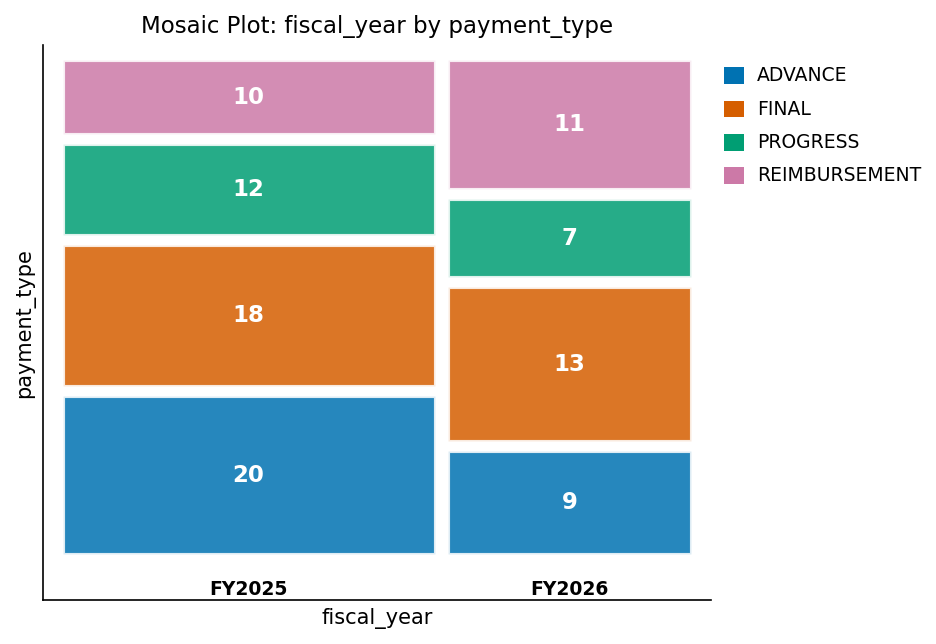

In [3]:
/* --------------------------------------------------------
   Baseline disbursement summary by agency and fiscal year
   -------------------------------------------------------- */
proc means data=work.disbursements n sum mean;
    class fiscal_year;
    var payment_amount;
run;

proc freq data=work.disbursements;
    tables fiscal_year * payment_type / nocum nopercent;
run;

---

NOTE: PROC SQL 

NOTE: Table work.agency_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.agency_summary

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


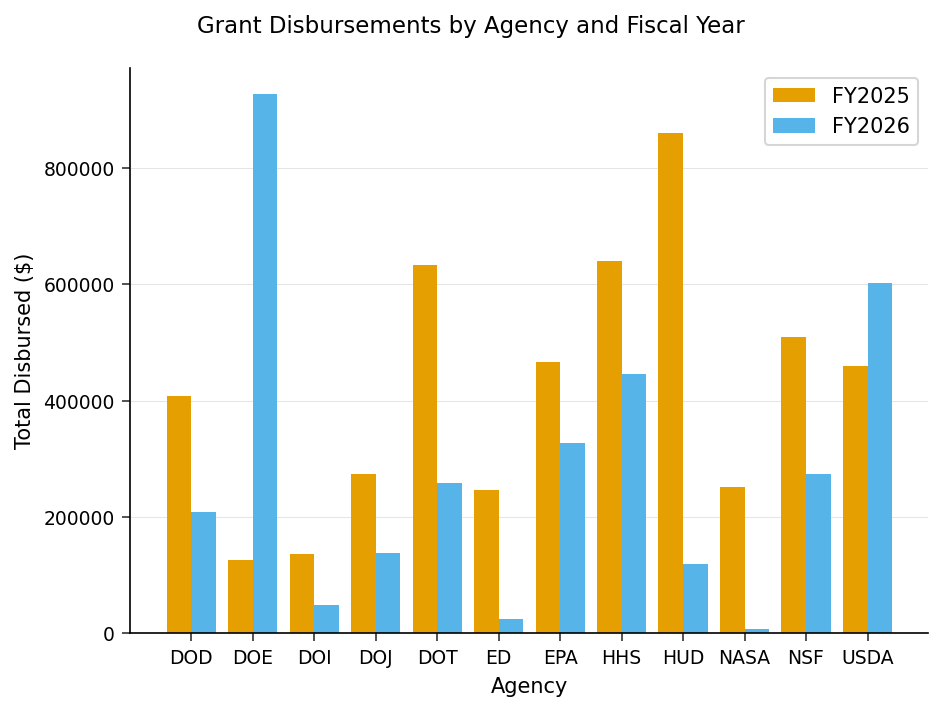

In [4]:
/* --------------------------------------------------------
   Disbursement flow by agency and fiscal year
   -------------------------------------------------------- */
proc sql;
    create table work.agency_summary as
    select d.fiscal_year, g.agency_code,
           sum(d.payment_amount) as total_disbursed
    from work.disbursements d
    inner join work.grant_master g on d.grant_id = g.grant_id
    group by d.fiscal_year, g.agency_code;
quit;

proc sgplot data=work.agency_summary;
    vbar agency_code / response=total_disbursed group=fiscal_year
        groupdisplay=cluster;
    xaxis label='Agency';
    yaxis label='Total Disbursed ($)' grid;
    title 'Grant Disbursements by Agency and Fiscal Year';
run;

---

In [5]:
/* --------------------------------------------------------
   Merge disbursements with grant master for agency detail
   -------------------------------------------------------- */
proc sort data=work.disbursements;
    by grant_id;
run;

proc sort data=work.grant_master;
    by grant_id;
run;

data work.ledger_detail;
    merge work.disbursements (in=a)
          work.grant_master (keep=grant_id agency_code agency_name grantee_name
                             award_amount grant_type in=b);
    by grant_id;
    if a and b;
run;

NOTE: PROC SORT data=work.disbursements

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.disbursements.
NOTE: Wrote work.disbursements (100 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.grant_master

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 80 rows from work.grant_master.
NOTE: Wrote work.grant_master (80 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ledger_detail

NOTE: Stream 1 processed 100 rows, max BY-group size: 5 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ledger_detail (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [6]:
/* --------------------------------------------------------
   Sort for BY-group processing by agency and fiscal year
   -------------------------------------------------------- */
proc sort data=work.ledger_detail;
    by agency_code fiscal_year payment_date;
run;

NOTE: PROC SORT data=work.ledger_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ledger_detail.
NOTE: Wrote work.ledger_detail (100 rows, 13 columns).
NOTE: PROC SORT statement used.


In [7]:
/* --------------------------------------------------------
   Print grant disbursement ledger with running SUM totals
   BY agency and fiscal year for hierarchical grouping
   SUM produces subtotals per BY-group and grand total
   -------------------------------------------------------- */
proc print data=work.ledger_detail noobs label;
    by agency_code fiscal_year;
    var grant_id grantee_name payment_date payment_type
        voucher_num payment_amount;
    sum payment_amount;
    label agency_code = 'Agency'
          fiscal_year = 'Fiscal Year'
          grant_id = 'Grant'
          grantee_name = 'Grantee'
          payment_date = 'Date'
          payment_type = 'Type'
          voucher_num = 'Voucher'
          payment_amount = 'Amount';
    format payment_amount dollar14.2;
    title1 'Federal Grant Disbursement Ledger';
    title2 'By Agency and Fiscal Year — Congressional Reporting';
run;

                                           Federal Grant Disbursement Ledger                                            
                                  By Agency and Fiscal Year — Congressional Reporting                                   

    Grant                Grantee       Date           Type     Voucher       Amount
Agency=DOD
Fiscal Year=FY2025

    Grant                Grantee       Date           Type     Voucher       Amount  
GR-000054  DUKE UNIVERSITY        12OCT2024  PROGRESS       VCH-000091   $66,222.15
GR-000070  CITY OF CHICAGO        14APR2025  ADVANCE        VCH-000022  $137,736.10
GR-000054  DUKE UNIVERSITY        14MAY2025  PROGRESS       VCH-000096   $23,922.64
GR-000070  CITY OF CHICAGO        19JUL2025  ADVANCE        VCH-000088   $81,156.48
GR-000078  COUNTY OF LOS ANGELES  06SEP2025  ADVANCE        VCH-000029   $22,084.80
GR-000031  UNIV OF MICHIGAN       17SEP2025  FINAL          VCH-000072   $76,420.84

Agency=DOD
Fiscal Year=FY2026

    Grant           

In [8]:
/* --------------------------------------------------------
   Reconciliation: compare disbursements vs award amounts
   -------------------------------------------------------- */
proc sql;
    select g.agency_code,
           g.grant_id,
           g.award_amount format=dollar14.2,
           sum(d.payment_amount) as total_disbursed format=dollar14.2,
           g.award_amount - sum(d.payment_amount) as remaining_balance format=dollar14.2,
           round(sum(d.payment_amount) / g.award_amount * 100, 0.1) as pct_drawn
    from work.grant_master g
    inner join work.disbursements d on g.grant_id = d.grant_id
    group by g.agency_code, g.grant_id, g.award_amount
    order by g.agency_code, pct_drawn desc;
quit;

                                           Federal Grant Disbursement Ledger                                            
                                  By Agency and Fiscal Year — Congressional Reporting                                   

Agency   Grant ID   Award Amount  total_disbursed  remaining_balance  pct_drawn
------  ---------  -------------  ---------------  -----------------  ---------
   DOD  GR-000070    $673,102.00      $218,892.58        $454,209.42       32.5
   DOD  GR-000031    $854,728.00      $148,958.29        $705,769.71       17.4
   DOD  GR-000077    $687,524.00       $97,073.37        $590,450.63       14.1
   DOD  GR-000054  $1,026,216.00      $113,235.34        $912,980.66       11.0
   DOD  GR-000033    $285,156.00       $14,760.45        $270,395.55        5.2
   DOD  GR-000078    $820,679.00       $22,084.80        $798,594.20        2.7
   DOE  GR-000058    $705,005.00      $316,514.23        $388,490.77       44.9
   DOE  GR-000014  $1,502,784.00     

---

### Interpretation

The disbursement ledger prints 100 payment transactions organized by agency (12 agencies) and fiscal year (FY2025 and FY2026), with the PROC PRINT SUM statement reporting a grand total of **$8,388,783.81** in disbursements across all BY groups. The PROC MEANS baseline splits this between **FY2025 ($5,012,340.86 across 60 payments, mean $83,539)** and **FY2026 ($3,376,442.95 across 40 payments, mean $84,411)**; the two fiscal years carry nearly identical average payment sizes, so the lower FY2026 total reflects fewer transactions in the window rather than smaller payments. By agency, HHS leads disbursement volume at roughly **$1.09M (5 grants)**, followed closely by USDA ($1.06M, 8 grants) and DOE ($1.05M, 4 grants).

The reconciliation query is where the audit value lands: it joins each disbursement back to its award and computes remaining balance and percent drawn. **Seven grants are over-drawn — disbursed more than 100% of their award amount — and carry negative remaining balances that must be cleared through obligation adjustment.** The most extreme is USDA grant GR-000029 at **292.5%** ($407,422.53 disbursed against a $139,271 award), with HUD GR-000034 (244.1%), USDA GR-000019 (173.1%), DOJ GR-000013 (172.0%), EPA GR-000017 (137.8%), USDA GR-000055 (130.6%), and NSF GR-000018 (120.6%) rounding out the exception list. The payment-type mosaic shows FY2025 weighted toward ADVANCE payments (20 of 60) while FY2026 is more evenly balanced across advance, progress, reimbursement, and final payments. Together, the hierarchical BY-group ledger with running SUM control totals and the percent-drawn reconciliation give GAO auditors the payment-level detail and the exception flags required for Single Audit closeout review.


---

In [9]:
/* --------------------------------------------------------
   Export ledger detail for GAO audit package
   -------------------------------------------------------- */
proc export data=work.ledger_detail
    outfile='grant_disbursement_ledger.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.ledger_detail outfile=grant_disbursement_ledger.csv

NOTE: Exported 100 rows to grant_disbursement_ledger.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>